## **Black Friday Sales Analysis**

### 🛒 Black Friday Analisis de Ventas

### ¿Por qué gastamos más durante el Black Friday?

💡 Viniste por un articulo
El Carrito Dice: **$1.200.000**

El Black Friday es uno de los eventos minoristas más poderosos del año. Los descuentos crean urgencia, los clientes se apresuran a obtener ofertas y los minoristas generan ingresos masivos dentro de una ventana promocional corta.

Este cuaderno analiza el conjunto de **datos de ventas del Black Friday** utilizando múltiples tipos de gráficos y la narración basada en la información.

### 🎯 ***Preguntas que Responderemos***

1. ¿ Qué Categorías de productos generan mas ingresos ?
2. ¿ Hay mayores descuentos que conduzcan a mayores ventas ?
3. ¿ Qué segmentos de clientes gastan más ?
4. ¿ Cuándo compran más los clientes ?
5. ¿ Podemos predecir el importe de la compra utilizando las funciones de transacción ?

### 📊  Imagenes Incluidas

> Gráficos de Barra

> Gráficos de Torta

> Gráficos de Linea

> Gráficos de Dispersión

> Histogramas

> Tabla de Segmentación de Clientes

> Importancia de la característica de ML

### ***1. Importación de Bibliotecas y Carga de Datos***

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

drive.mount('/content/drive')

NOMBRE_CARPETA_DRIVE = 'DataSet'

PATH_BASE = f'/content/drive/MyDrive/DataSet/'

path_final = os.path.join(PATH_BASE, 'retail_black_friday_sales_100k.csv')

df = pd.read_csv(path_final)
df.head()

Mounted at /content/drive


,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35,99.92,1,99.92,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40,138.03,1,138.03,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25,131.00,1,131.00,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40,239.77,1,239.77,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30,84.61,2,169.22,Debit Card,2025-11-25,2,0,0


### ***2. Resumen del Conjunto de Datos***

In [3]:
print("Shape: ", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

df.describe(include='all').T

Shape:  (100000, 18)

Columns:
['transaction_id', 'customer_id', 'age_group', 'gender', 'city', 'customer_segment', 'product_id', 'product_category', 'original_price', 'discount_pct', 'final_price', 'quantity', 'purchase_amount', 'payment_method', 'purchase_date', 'purchase_hour', 'is_weekend', 'is_black_friday']

Missing values:
transaction_id      0
customer_id         0
age_group           0
gender              0
city                0
customer_segment    0
product_id          0
product_category    0
original_price      0
discount_pct        0
final_price         0
quantity            0
purchase_amount     0
payment_method      0
purchase_date       0
purchase_hour       0
is_weekend          0
is_black_friday     0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,100000,100000,T0099984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,32997,C016694,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,100000,5,36-45,20145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,100000,3,Female,33460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,100000,10,New York,10105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,4,Returning,34946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,100000,9000,P9694,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,100000,10,Accessories,10156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,100000.0,NaN,NaN,NaN,330.281911,444.315916,5.0,88.1175,180.22,333.7125,2499.89
discount_pct,100000.0,NaN,NaN,NaN,26.63115,12.249229,5.0,20.0,25.0,35.0,60.0


#### 2.1 Información Util

Este conjunto de datos contiene atributos de cliente, producto, precio, descuento y tiempo de compra.

Eso lo hace útil para el **análisis minorista**, **el análisis del comportamiento del cliente**, **la estrategia de descuento** y el **aprendizaje automático**.

### ***3. **Black Friday** Resumen de Ventas***

In [4]:
total_transactions = len(df)
total_revenue = df["purchase_amount"].sum()
avg_order_value = df["purchase_amount"].mean()
total_units = df["quantity"].sum()
avg_discount = df["discount_pct"].mean()

snapshot = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Revenue",
        "Average Order Value",
        "Total Units Sold",
        "Average Discount"
    ],
    "Value": [
        f"{total_transactions:,}",
        f"${total_revenue:,.2f}",
        f"${avg_order_value:,.2f}",
        f"{total_units:,}",
        f"{avg_discount:.2f}%"
    ]
})

snapshot

,Metric,Value
0,Total Transactions,"100,000"
1,Total Revenue,"$35,125,630.67"
2,Average Order Value,$351.26
3,Total Units Sold,"144,729"
4,Average Discount,26.63%


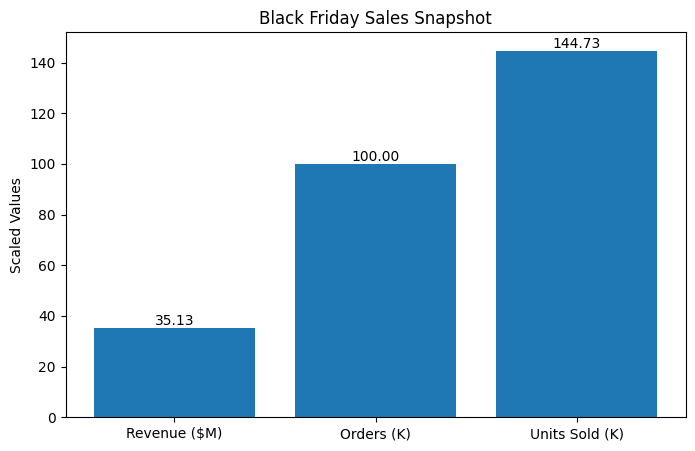

In [5]:
plt.figure(figsize=(8, 5))
metrics = ["Revenue ($M)", "Orders (K)", "Units Sold (K)"]
values = [total_revenue / 1_000_000, total_transactions / 1000, total_units / 1000]

bars = plt.bar(metrics, values)
plt.title("Black Friday Sales Snapshot")
plt.ylabel("Scaled Values")

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f}", ha='center', va='bottom')

plt.show()

#### 3.1 Conocimiento

Esta instantánea ofrece una comprensión rápida del rendimiento general del Black Friday: transacciones totales, ingresos totales y volumen de compras.

### ***4. Ingreso de la categoria de Producto***

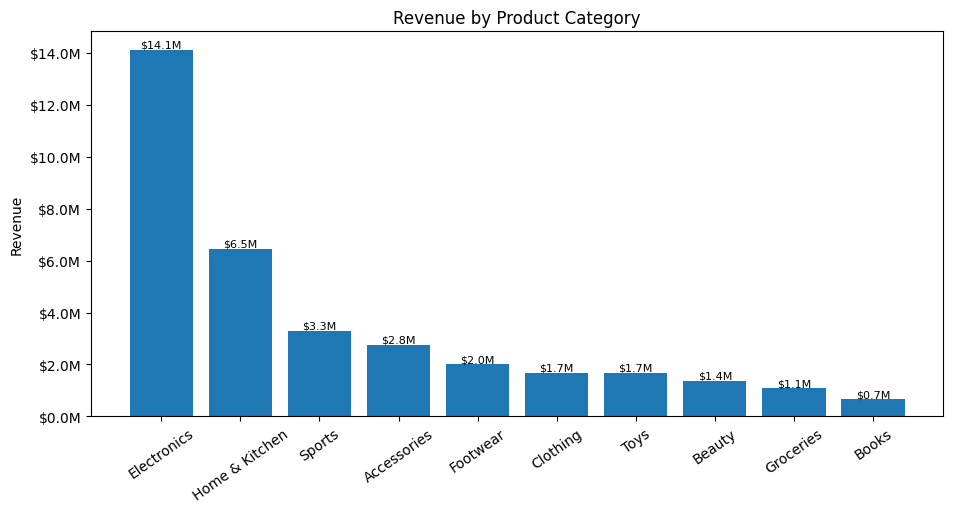

,purchase_amount
product_category,
Electronics,14123441.47
Home & Kitchen,6461099.92
Sports,3303563.29
Accessories,2754561.54
Footwear,2013317.39
Clothing,1688471.88
Toys,1669209.91
Beauty,1374751.97
Groceries,1075986.12


In [6]:
category_revenue = df.groupby('product_category')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
bars = plt.bar(category_revenue.index, category_revenue.values)
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=35)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom', fontsize=8)

plt.show()
category_revenue

#### 4.1 Información Util

Este gráfico muestra qué categorías de productos generaron la mayor parte de los ingresos del Viernes Negro.

Las categorías de altos ingresos suelen ser los mayores objetivos para las promociones, la planificación del inventario y la optimización de campañas.

### ***5. Participación de los ingresos por categoría - Gráfico Circular***

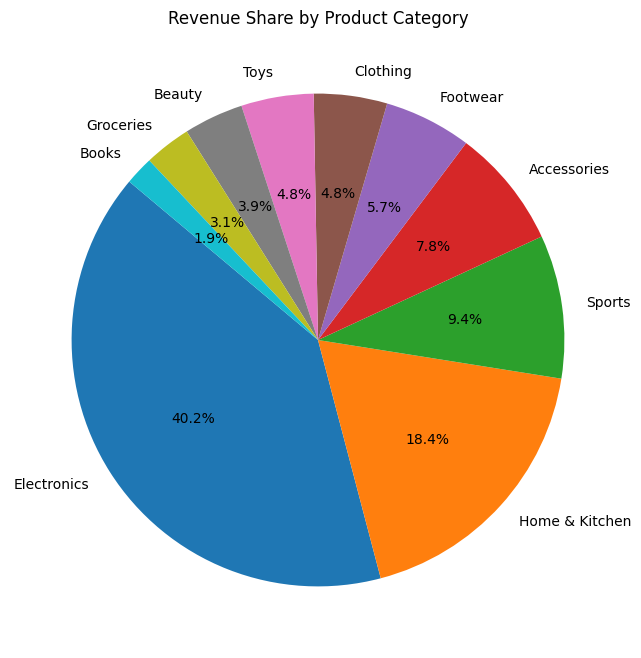

In [7]:
plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Revenue Share by Product Category")
plt.show()

#### 5.1 - Información Util

Los gráficos circulares ayudan a comprender rápidamente la contribución de cada categoría. 

Durante los principales eventos de venta minorista, algunas categorías suelen dominar ventas totales.

### ***6. Unidades vendidas por categoría***


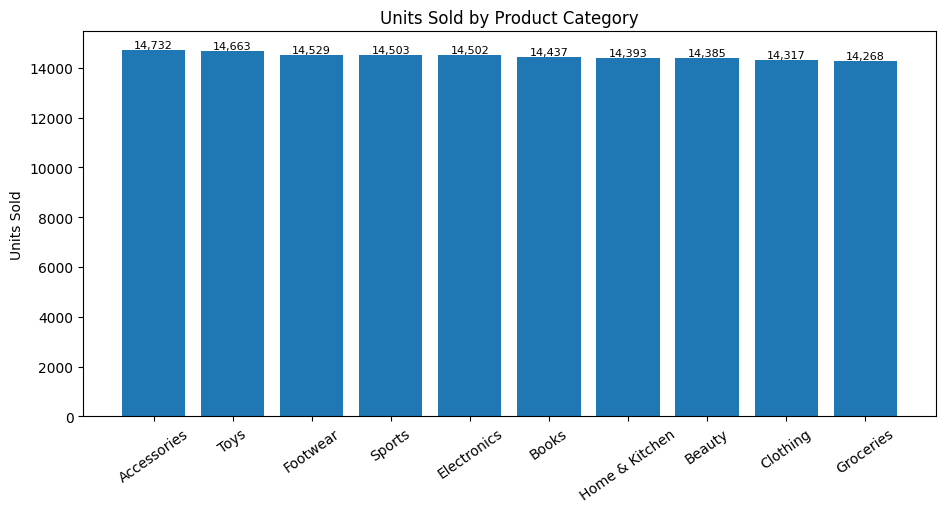

,quantity
product_category,
Accessories,14732
Toys,14663
Footwear,14529
Sports,14503
Electronics,14502
Books,14437
Home & Kitchen,14393
Beauty,14385
Clothing,14317


In [8]:
category_units = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
bars = plt.bar(category_units.index, category_units.values)
plt.title("Units Sold by Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=35)

for bar, value in zip(bars, category_units.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}", ha='center', va='bottom', fontsize=8)

plt.show()
category_units

#### 6.1 Dato Util

Los ingresos y el volumen de ventas no siempre coinciden.

Algunas categorías pueden vender muchas unidades, pero generar menores ingresos debido a precios más bajos.

### ***7. Distibución de Descuentos***

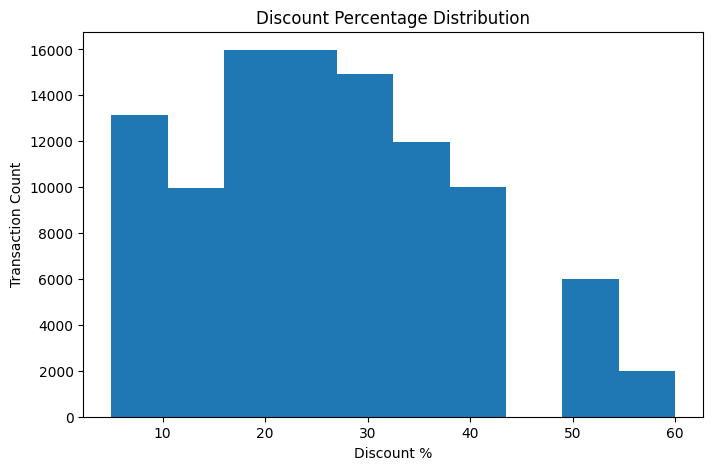

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['discount_pct'], bins=10)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.ylabel("Transaction Count")
plt.show()

#### 7.1 Dato Util

La distribución de los descuentos muestra la agresividad de la estrategia de promoción del Black Friday.

Una alta concentración en torno a ciertos niveles de descuento puede indicar la planificación de diferentes niveles promocionales.

### ***8. Descuento frente al gasto Promedio: Gráfico Linaal***

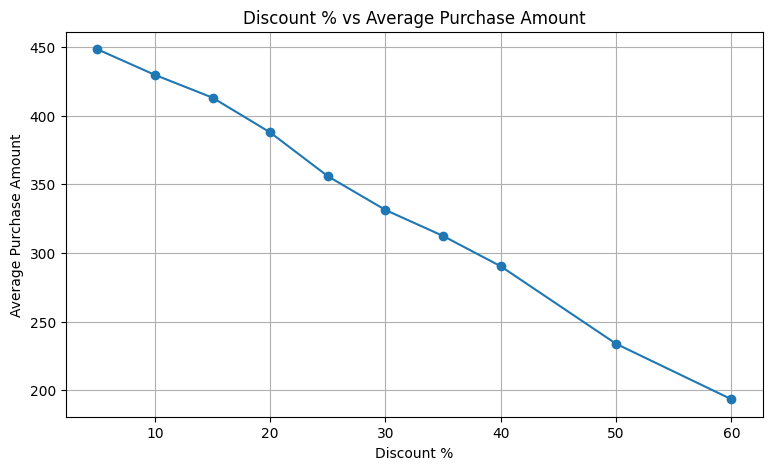

,purchase_amount
discount_pct,
5,448.325459
10,429.643738
15,413.057351
20,387.727121
25,355.864005
30,331.273828
35,312.358172
40,290.280333
50,233.851908


In [10]:
discount_avg = df.groupby('discount_pct')['purchase_amount'].mean()

plt.figure(figsize=(9, 5))
plt.plot(discount_avg.index, discount_avg.values, marker='o')
plt.title("Discount % vs Average Purchase Amount")
plt.xlabel("Discount %")
plt.ylabel("Average Purchase Amount")
plt.grid(True)
plt.show()

discount_avg

#### 8.1 Dato Util

Mayores descuentos no siempre significan mayor gasto.

A veces, los descuentos moderados logran el mejor equilibrio entre urgencia e ingresos.

### ***9. Descuento vs. Monto de compra: diagrama de dispersión***

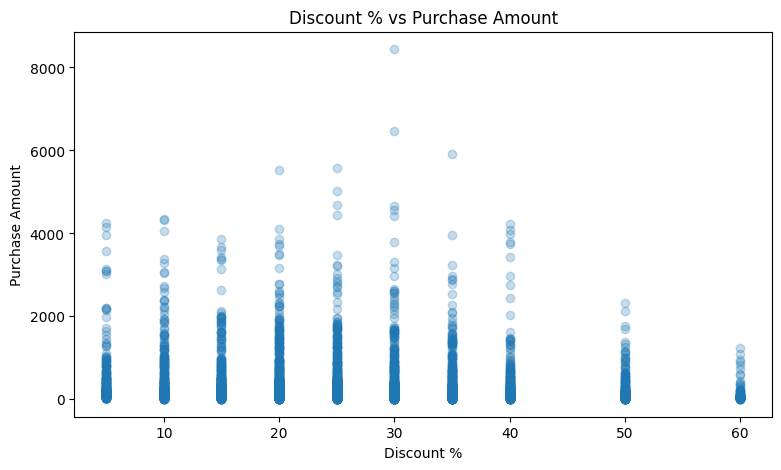

In [11]:
sample = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(sample['discount_pct'], sample['purchase_amount'], alpha=0.25)
plt.title("Discount % vs Purchase Amount")
plt.xlabel("Discount %")
plt.ylabel("Purchase Amount")
plt.show()

#### 9.1 Dato Util

Los diagramas de dispersión ayudan a revelar si los descuentos elevados conducen sistemáticamente a compras de mayor importe.
Esto resulta útil para evaluar la eficacia de los descuentos.

### ***10. Ingresos del segmento de clientes***

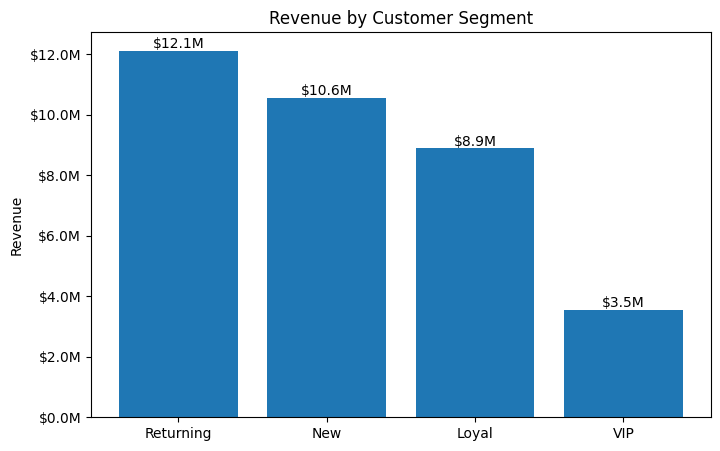

,purchase_amount
customer_segment,
Returning,12125507.74
New,10574443.42
Loyal,8888416.70
VIP,3537262.81


In [12]:
segment_revenue = df.groupby('customer_segment')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_revenue.index, segment_revenue.values)
plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, segment_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom')

plt.show()
segment_revenue

#### 10.1 Información Util

El análisis de segmentos de clientes ayuda a identificar qué grupos generan mayores ingresos.

Esto permite diseñar campañas específicas y programas de fidelización.

### ***11. Cuota de mercado por segmento de clientes — Gráfico circular***

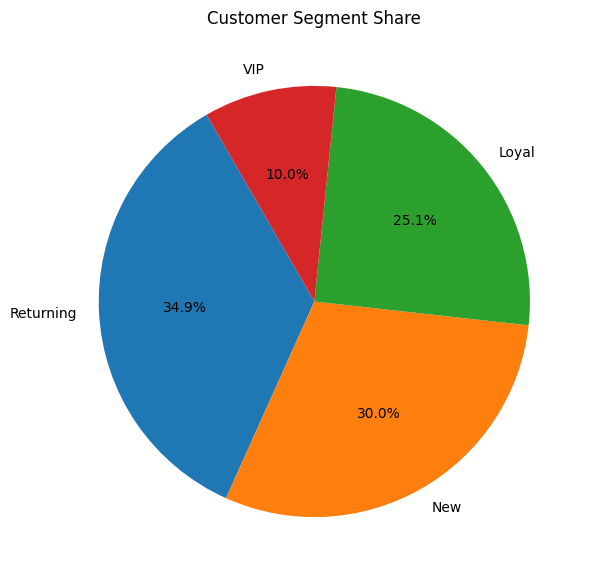

In [13]:
segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=120
)
plt.title("Customer Segment Share")
plt.show()

#### 11.1 Información Util

Este gráfico ayuda a comprender la composición de la clientela durante el Black Friday.

Un alto porcentaje de clientes recurrentes o leales puede indicar una buena retención y confianza en la marca.

### ***12. Valor promedio del pedido por segmento***

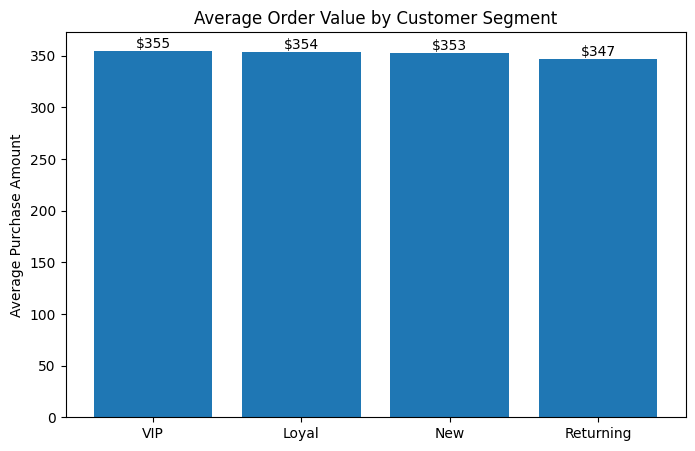

,purchase_amount
customer_segment,
VIP,354.861839
Loyal,353.697441
New,352.999179
Returning,346.978416


In [14]:
segment_aov = df.groupby('customer_segment')['purchase_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_aov.index, segment_aov.values)
plt.title("Average Order Value by Customer Segment")
plt.ylabel("Average Purchase Amount")

for bar, value in zip(bars, segment_aov.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value:.0f}", ha='center', va='bottom')

plt.show()
segment_aov

#### 12.1 Insight

Average order value helps identify high-value customer groups.
VIP and loyal segments often generate higher basket sizes.

### ***13. Ingresos por ciudad***

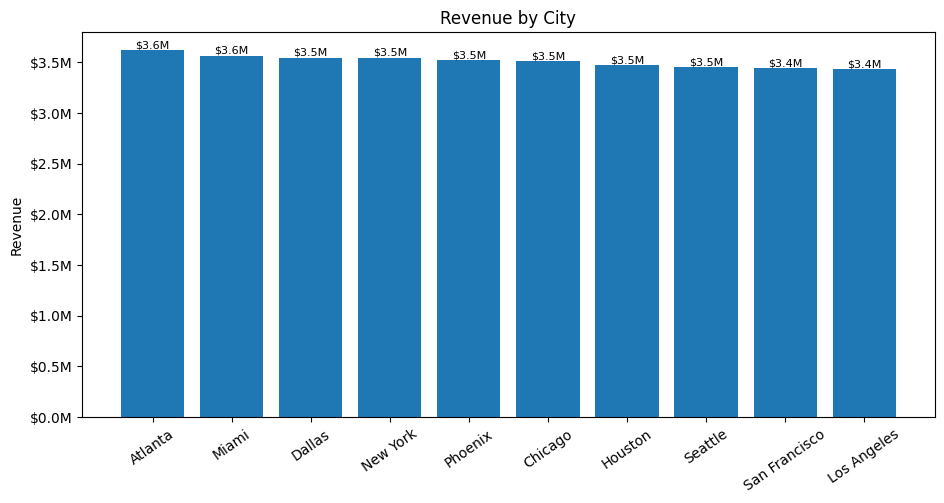

,purchase_amount
city,
Atlanta,3618348.52
Miami,3566829.80
Dallas,3547967.43
New York,3546500.70
Phoenix,3526014.43
Chicago,3512360.63
Houston,3474957.45
Seattle,3456842.39
San Francisco,3445376.30


In [15]:
city_revenue = df.groupby('city')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
bars = plt.bar(city_revenue.index, city_revenue.values)
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=35)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, city_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom', fontsize=8)

plt.show()
city_revenue

#### 13.1 Información Util

El análisis a nivel de ciudad ayuda a identificar patrones de demanda regional.

Esto es útil para el marketing local y la distribución de inventario.

### ***14. Ingresos por métodos de pago***

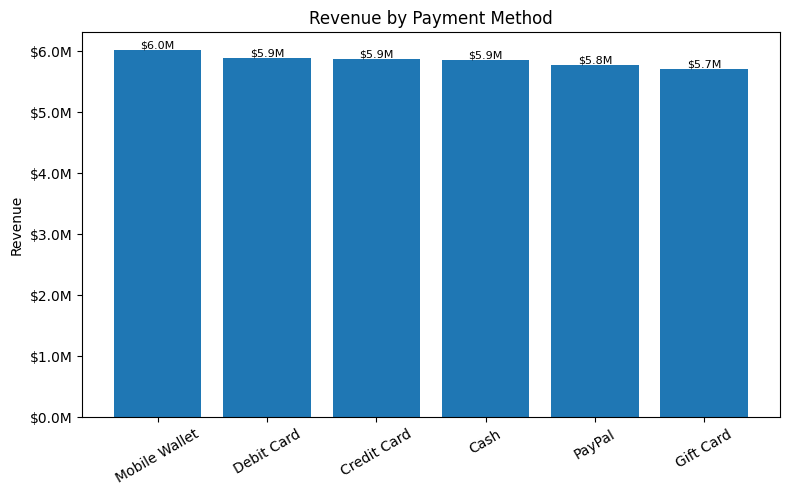

,purchase_amount
payment_method,
Mobile Wallet,6020177.60
Debit Card,5892551.34
Credit Card,5877297.96
Cash,5856797.42
PayPal,5770589.41
Gift Card,5708216.94


In [16]:
payment_revenue = df.groupby('payment_method')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(payment_revenue.index, payment_revenue.values)
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, payment_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom', fontsize=8)

plt.show()
payment_revenue

#### 14.1 Análisis Util

El análisis de los métodos de pago revela las preferencias de compra.
Durante el Black Friday, las opciones de pago rápidas y convenientes pueden mejorar la tasa de conversión.

### ***15. Distribución de cantidad de compra***

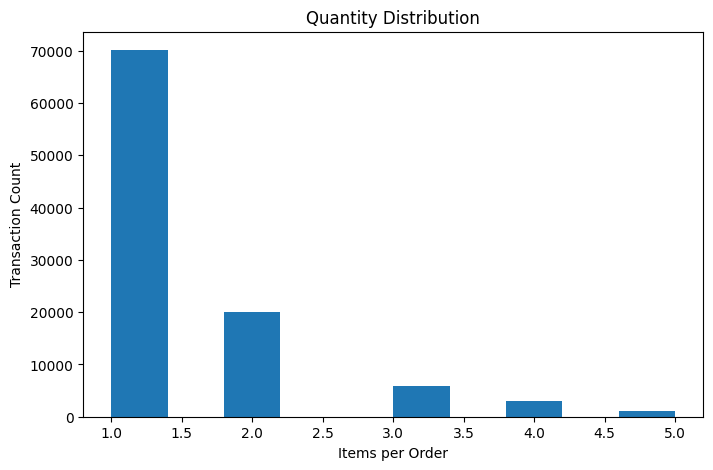

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['quantity'], bins=10)
plt.title("Quantity Distribution")
plt.xlabel("Items per Order")
plt.ylabel("Transaction Count")
plt.show()

#### 15.1 Análisis Útil

La distribución de la cantidad muestra si los clientes suelen comprar un solo artículo o varios por transacción.

Esto ayuda a comprender el comportamiento del tamaño de la cesta de compra.

### ***16. Ventas por fecha — Gráfico de líneas***

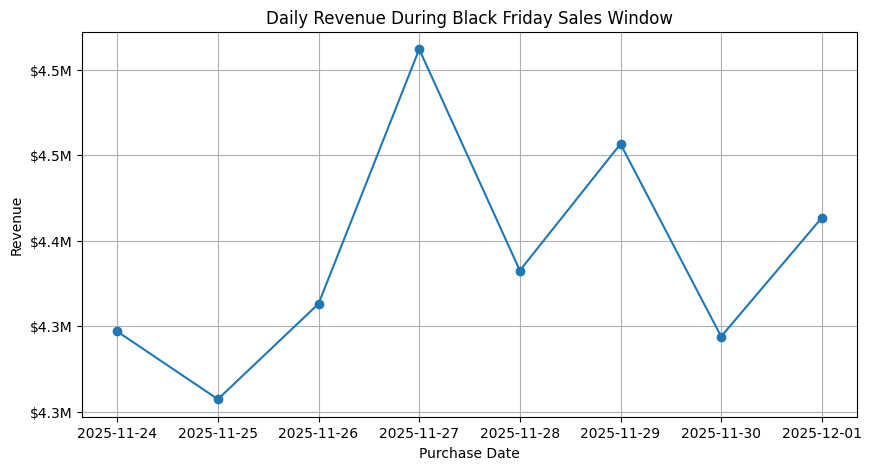

,purchase_amount
purchase_date,
2025-11-24,4346855.88
2025-11-25,4307207.06
2025-11-26,4363080.64
2025-11-27,4512050.40
2025-11-28,4382528.94
2025-11-29,4456611.01
2025-11-30,4343881.32
2025-12-01,4413415.42


In [18]:
daily_sales = df.groupby('purchase_date')['purchase_amount'].sum()

plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title("Daily Revenue During Black Friday Sales Window")
plt.xlabel("Purchase Date")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.grid(True)
plt.show()

daily_sales

#### 16.1 Análisis Importante

Los ingresos diarios muestran cómo aumentan las ventas en torno al Black Friday.

Esto puede revelar si los clientes compran con anticipación, esperan al evento principal o continúan comprando después del evento.

### ***17. Ventas por hora — Gráfico de líneas***

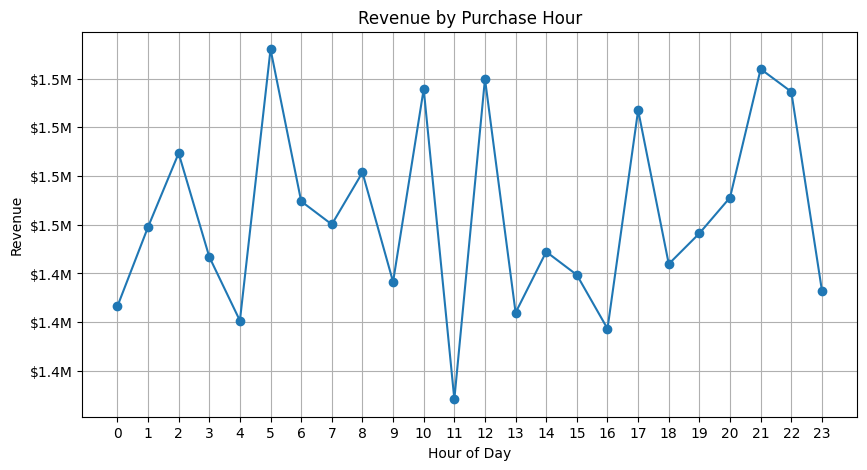

,purchase_amount
purchase_hour,
5,1532048.19
21,1523919.80
12,1519856.72
10,1515714.84
22,1514587.52


In [19]:
hourly_sales = df.groupby('purchase_hour')['purchase_amount'].sum()

plt.figure(figsize=(10, 5))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o')
plt.title("Revenue by Purchase Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.grid(True)
plt.show()

hourly_sales.sort_values(ascending=False).head()

#### 17.1 Análisis Importante

Los patrones de ventas por hora ayudan a identificar los periodos de mayor afluencia.
Los minoristas pueden utilizar esta información para ventas relámpago, planificación de personal, publicidad y capacidad del sistema.


### ***18. Black Friday frente a otros días de rebajas***

In [20]:
bf_comparison = df.groupby('is_black_friday')['purchase_amount'].agg(['count', 'sum', 'mean'])
bf_comparison.index = ['Other Sale Days', 'Black Friday']

bf_comparison

,count,sum,mean
Other Sale Days,87367,30743101.73,351.884599
Black Friday,12633,4382528.94,346.911180


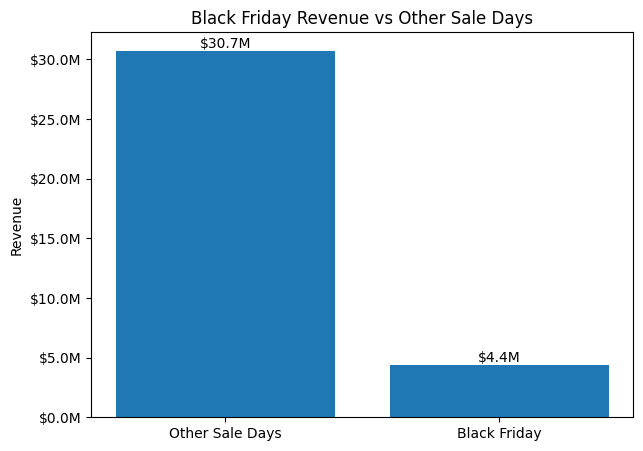

In [21]:
plt.figure(figsize=(7, 5))
bars = plt.bar(bf_comparison.index, bf_comparison['sum'])
plt.title("Black Friday Revenue vs Other Sale Days")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, bf_comparison['sum']):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom')

plt.show()

#### 18.1 Análisis Importante

Esta comparación muestra si la fecha del Black Friday generó más ingresos que los días promocionales cercanos.

### ***19. Ventas de fin de semana frente a ventas entre semana***

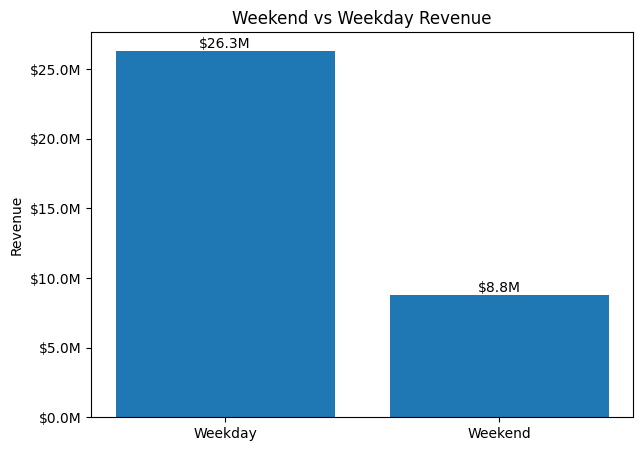

,purchase_amount
Weekday,26325138.34
Weekend,8800492.33


In [22]:
weekend_sales = df.groupby('is_weekend')['purchase_amount'].sum()
weekend_sales.index = ['Weekday', 'Weekend']

plt.figure(figsize=(7, 5))
bars = plt.bar(weekend_sales.index, weekend_sales.values)
plt.title("Weekend vs Weekday Revenue")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar, value in zip(bars, weekend_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"${value/1e6:.1f}M", ha='center', va='bottom')

plt.show()

weekend_sales

#### 19.1 Análisis Importante

Las comparaciones entre fines de semana y días laborables pueden ayudar a los minoristas a planificar campañas en función de la disponibilidad de los productos y los hábitos de compra de los clientes.

### ***20. Machine Learning - Predicción del importe de la compra***

In [23]:
df_model = df.copy()

categorical_cols = [
    'age_group',
    'gender',
    'city',
    'customer_segment',
    'product_category',
    'payment_method'
]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

features = [
    'original_price',
    'discount_pct',
    'final_price',
    'quantity',
    'purchase_hour',
    'is_weekend',
    'is_black_friday'
] + [col for col in df_encoded.columns if any(prefix in col for prefix in [
    'age_group_', 'gender_', 'city_', 'customer_segment_', 'product_category_', 'payment_method_'
])]

X = df_encoded[features]
y = df_encoded['purchase_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE: 0.29
RMSE: 3.26
R² Score: 1.0


### ***21. Importe de compra real frente al importe previsto***

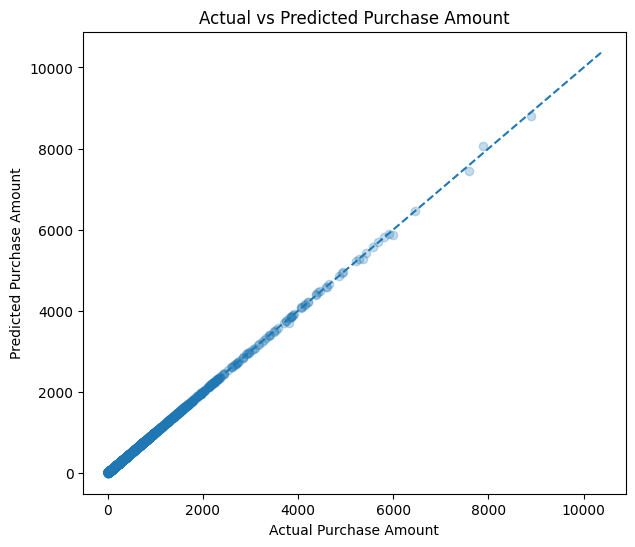

In [24]:
sample_size = min(5000, len(y_test))
sample_idx = np.random.choice(len(y_test), size=sample_size, replace=False)

plt.figure(figsize=(7, 6))
plt.scatter(np.array(y_test)[sample_idx], np.array(y_pred)[sample_idx], alpha=0.25)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')
plt.title("Actual vs Predicted Purchase Amount")
plt.xlabel("Actual Purchase Amount")
plt.ylabel("Predicted Purchase Amount")
plt.show()

#### 21.1 Análisis Importante

El modelo puede estimar el monto de compra utilizando precios, descuentos, cantidad, momento de compra y atributos del cliente/producto.

Esto resulta útil para pronosticar ingresos y comprender los factores que influyen en las compras.

### ***22. Importancia de las características***

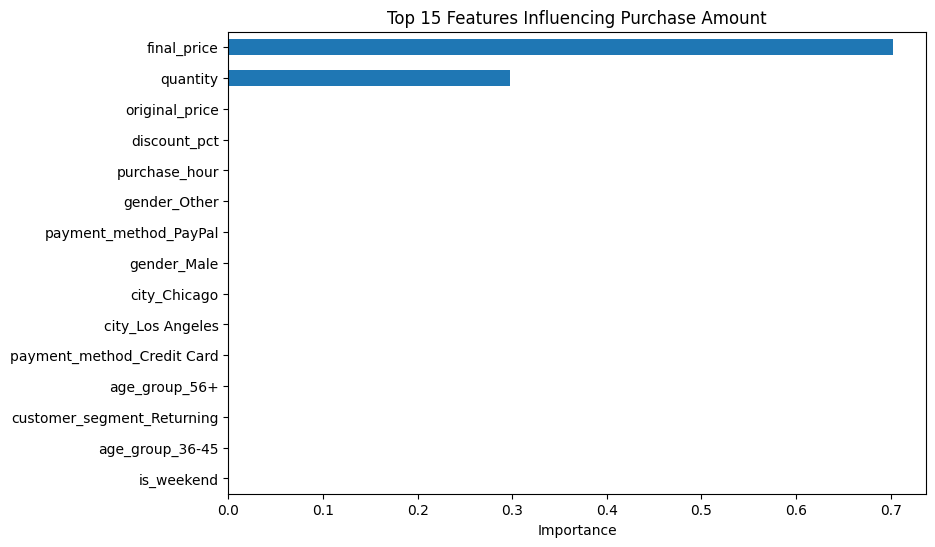

,0
final_price,0.702306
quantity,0.297490
original_price,0.000055
discount_pct,0.000041
purchase_hour,0.000020
gender_Other,0.000011
payment_method_PayPal,0.000009
gender_Male,0.000007
city_Chicago,0.000006
city_Los Angeles,0.000005


In [25]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind='barh')
plt.title("Top 15 Features Influencing Purchase Amount")
plt.xlabel("Importance")
plt.show()

importance

#### 22.1 Análisis Importante

La importancia de las características ayuda a explicar qué impulsa el gasto.

Por lo general, el monto de la compra está fuertemente influenciado por el precio, el descuento, la cantidad y las señales de la categoría.

### ***23. Análisis Final***

## 🧠 Lo que aprendimos

1. **El gasto del Black Friday está impulsado por las categorías de productos.:**
    Algunas categorías generan mayores ingresos debido a una mayor demanda o a precios más elevados de los productos.

2. **Los descuentos importan, pero más grande no siempre es mejor.:**
    Los descuentos moderados pueden generar un comportamiento de compra más sólido que los descuentos extremos.

3. **Los segmentos de clientes se comportan de manera diferente.:**
    Los clientes VIP, leales, recurrentes y nuevos muestran patrones de gasto diferentes.

4. **El tiempo importa:**
    La fecha y la hora de compra revelan los momentos de mayor actividad de compra.

5. **El aprendizaje automático (Machine Learning) puede ayudar a planificar:**
    La predicción del importe de las compras puede ser útil para la elaboración de pronósticos, la planificación de campañas y la gestión de inventario.

### 🚀 Aplicaciones Comerciales

This dataset can support:

* Paneles de ventas del Black Friday.

* Análisis del comportamiento de compra del cliente.

* Modelado de impacto.

* Predicción de ingresos.

* Análisis de rendimiento de categoría de producto.

* Segmentación de clientes.

* Retail machine learning projects.